### 1) Import Pandas and Numpy

In [1]:
#your code here
import numpy as np
import pandas as pd

### 2) Import the dataset and  Assign it to a variable called Chipo

#### Import the dataset from
https://github.com/justmarkham/pandas-videos/blob/master/data/chipotle.tsv

#### REMEMBER: It is a .tsv file , you will have to do some research on how to read .tsv files first!

In [2]:
#your code here
chipo = pd.read_csv('https://raw.githubusercontent.com/justmarkham/pandas-videos/refs/heads/master/data/chipotle.tsv', sep='\t')
chipo                               #Requires Internet.

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
...,...,...,...,...,...
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75


### 3) See the first 10 entries

In [3]:
#your code here
print(chipo.head(10))

   order_id  quantity                              item_name  \
0         1         1           Chips and Fresh Tomato Salsa   
1         1         1                                   Izze   
2         1         1                       Nantucket Nectar   
3         1         1  Chips and Tomatillo-Green Chili Salsa   
4         2         2                           Chicken Bowl   
5         3         1                           Chicken Bowl   
6         3         1                          Side of Chips   
7         4         1                          Steak Burrito   
8         4         1                       Steak Soft Tacos   
9         5         1                          Steak Burrito   

                                  choice_description item_price  
0                                                NaN     $2.39   
1                                       [Clementine]     $3.39   
2                                            [Apple]     $3.39   
3                              

### 4) What is the number of observations in the dataset?

In [4]:
#your code here
n = chipo['choice_description'].isna().value_counts().values[1]#NaN dectected
print(f'There are {chipo.shape[0]} rows')
print(f'Total no of elements : {chipo.shape[0]*chipo.shape[1] - n}')


There are 4622 rows
Total no of elements : 21864


### 5) What is the number of columns in the dataset?

In [5]:
#your code here
print("No of columns :", chipo.shape[1])

No of columns : 5


### 6) Print the name of all the columns.

In [6]:
#your code here
print(f"Columns names : {', '.join(chipo.columns)}")

Columns names : order_id, quantity, item_name, choice_description, item_price


### 7) Which was the most-ordered item?

In [7]:
#your code here
print(chipo['item_name'].value_counts().sort_values(ascending=False).index[0], 'is the most ordered item')

Chicken Bowl is the most ordered item


### 8) For the most-ordered item, how many items were ordered?

In [8]:
#your code here
print(chipo[chipo['item_name'] == 'Chicken Bowl']['quantity'].sum(), 'Chicken Bowls were ordered')

761 Chicken Bowls were ordered


### 9) What was the most ordered item in the choice_description column?

In [9]:
#your code here
from collections import defaultdict #TO GET THE C++ STYLE DICTIONARY(MAP).
chipo['choice_description'] = chipo['choice_description'].str.replace('[', '')
chipo['choice_description'] = chipo['choice_description'].str.replace(']', '')
l = defaultdict(int)
def fun(a):
    if(type(a) == str):
        li = a.split(', ')
        for j in li:
            if(j):
                l[j]+=1

chipo['choice_description'].apply(fun)
m = max(l.values())
k = ''
for i in l:
    if(l[i] == m):
        k = i
print("The item which was ordered the most was :", k,'(', m, 'times )')   


The item which was ordered the most was : Rice ( 2389 times )


### 10) How many items were ordered in total?

In [10]:
#your code here
print(chipo['quantity'].sum(), 'were ordered in total')



4972 were ordered in total


### 11) Turn the item price into a float

In [11]:
#your code here
chipo['item_price'] = chipo['item_price'].str.replace('$','').astype(float)
print(chipo.dtypes)
chipo.head(10)

order_id                int64
quantity                int64
item_name              object
choice_description     object
item_price            float64
dtype: object


,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39
1,1,1,Izze,Clementine,3.39
2,1,1,Nantucket Nectar,Apple,3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39
4,2,2,Chicken Bowl,"Tomatillo-Red Chili Salsa (Hot), Black Beans, ...",16.98
5,3,1,Chicken Bowl,"Fresh Tomato Salsa (Mild), Rice, Cheese, Sour ...",10.98
6,3,1,Side of Chips,NaN,1.69
7,4,1,Steak Burrito,"Tomatillo Red Chili Salsa, Fajita Vegetables, ...",11.75
8,4,1,Steak Soft Tacos,"Tomatillo Green Chili Salsa, Pinto Beans, Chee...",9.25
9,5,1,Steak Burrito,"Fresh Tomato Salsa, Rice, Black Beans, Pinto B...",9.25


### 12) How much was the revenue for the period in the dataset?
#### Revenue will be the sum of quantity * item_price!

In [12]:
#your code here
x = chipo['quantity']*chipo['item_price']
print("The revenue for the period in the dataset is :",x.sum())

The revenue for the period in the dataset is : 39237.02


### 13) How many orders were made in the period?

In [13]:
#your code here
print(chipo['order_id'].max(),'orders were made in the period')

1834 orders were made in the period


### 14) What is the average revenue amount per order?

In [14]:
#your code here
avg = (x.sum())/(chipo['order_id'].max())
print('%.2f' % avg, "is the avg revenue per order.")

21.39 is the avg revenue per order.


### 15) How many different items are sold?

In [15]:
#your code here
print(len(set(chipo['item_name'])), 'different items are sold.')

50 different items are sold.


### 16) Show a histogram with number of orders with bill on the x-axis.

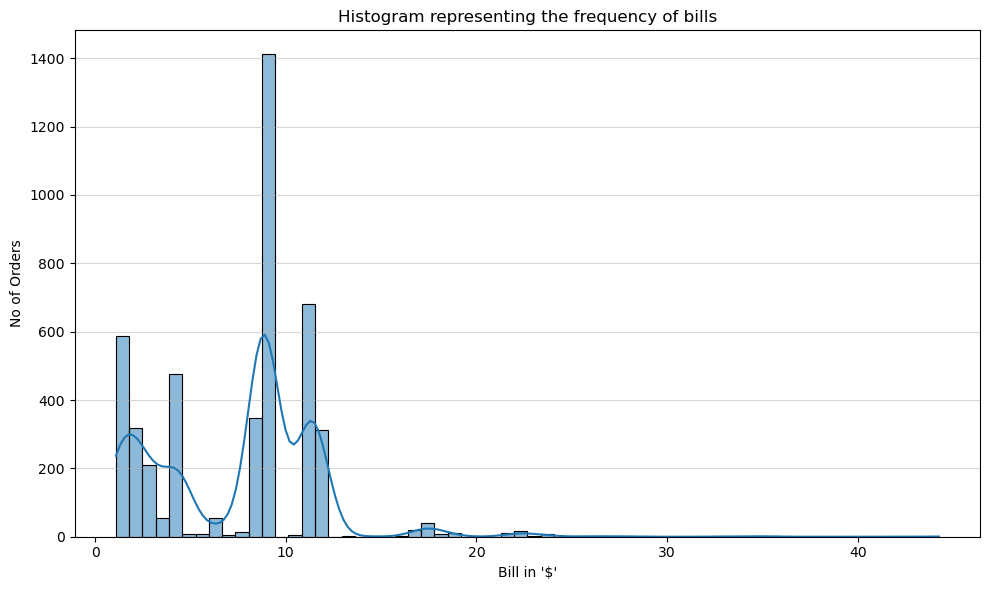

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
fig , ax = plt.subplots(figsize= (10, 6))
ax = sns.histplot(data= chipo, x='item_price', kde= True)
ax.set(xlabel = "Bill in '$'", ylabel = 'No of Orders', title = "Histogram representing the frequency of bills")
ax.grid(axis='y', alpha = 0.5)
plt.tight_layout()
plt.show()
fig.savefig('assignment-2.png', dpi = 300, bbox_inches = 'tight', pad_inches = 1)